--- Data Berhasil Dimuat dan Dibersihkan ---
   Order_ID  CustomerID Order_Date Product_Category  Quantity  Price_Per_Unit  \
0      1001        5039 2023-08-19            Books         4       1184000.0   
1      1002        5029 2023-08-29          Fashion         5       1733000.0   
2      1003        5015 2023-02-21          Fashion         4       1767000.0   
3      1004        5043 2023-04-06          Fashion         2        512000.0   
4      1005        5008 2023-08-10       Home Decor         2       1820000.0   

   Ad_Budget  Total_Sales  
0   982000.0    4736000.0  
1  3513000.0    8665000.0  
2  2117000.0    7068000.0  
3  4384000.0    1024000.0  
4  2625000.0    3640000.0  




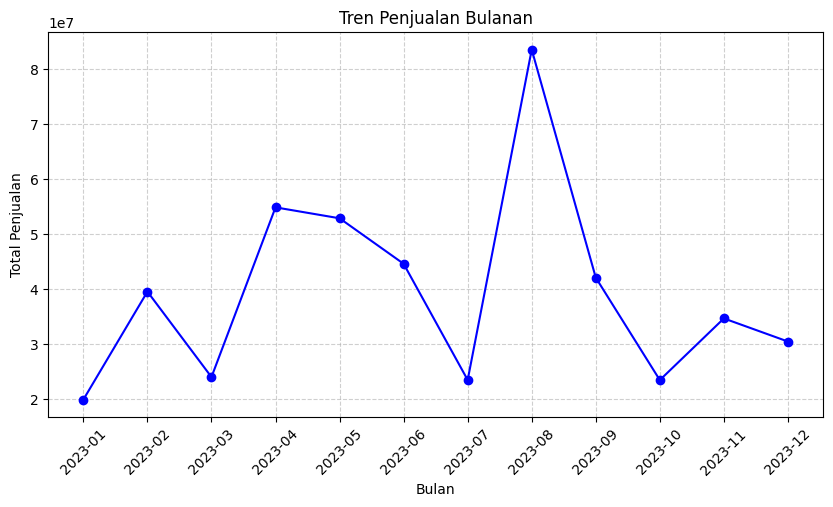

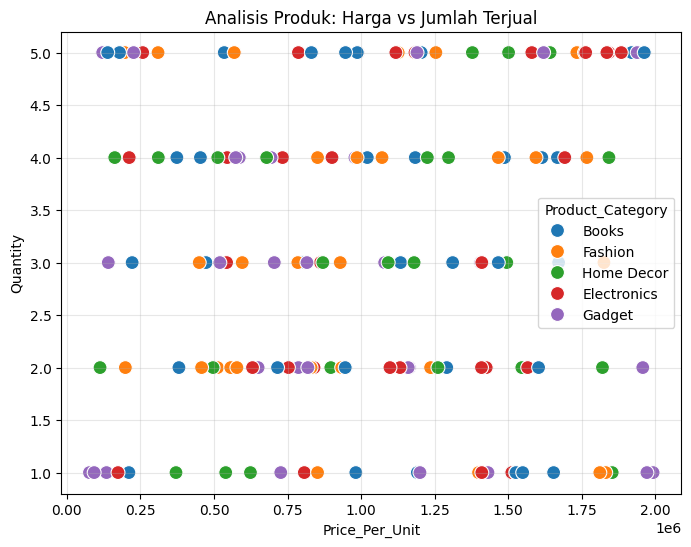

--- Hasil Analisis RFM ---
            Recency  Frequency    Monetary
CustomerID                                
5001            213          4   8562000.0
5002             77          4   8983000.0
5003            118          3   9433000.0
5004            196          3  20268000.0
5005             23          2   9105000.0


--- Hasil Regresi Linear Sederhana ---
Intercept (Beta 0): 2994695.0757475323
Koefisien Iklan (Beta 1): 0.06131915283465149
Akurasi Model (R2 Score): 0.001225304601044308


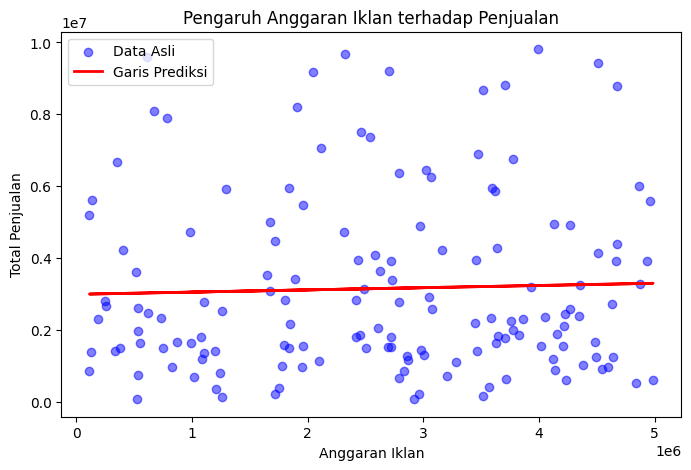

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. MEMBACA DATA
# Pastikan nama file sesuai dengan yang ada di folder samping Google Colab kamu
nama_file = 'data_praktikum_analisis_data - data_praktikum_analisis_data.csv'
df = pd.read_csv(nama_file)

# 2. PEMBERSIHAN DATA (DATA WRANGLING)
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
# Mengisi Total Sales yang kosong (Quantity * Price_Per_Unit)
df['Total_Sales'] = df['Quantity'] * df['Price_Per_Unit']

print("--- Data Berhasil Dimuat dan Dibersihkan ---")
print(df.head())
print("\n")

# 3. ANALISIS TREN PENJUALAN BULANAN (Kode yang kamu tanyakan)
# Membuat kolom bulan untuk pengelompokan
df['Month'] = df['Order_Date'].dt.to_period('M').astype(str)
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='b', linestyle='-')
plt.title('Tren Penjualan Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Total Penjualan')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 4. VISUALISASI PRODUK UNDERPERFORMER (Scatter Plot)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Price_Per_Unit', y='Quantity', hue='Product_Category', s=100)
plt.title('Analisis Produk: Harga vs Jumlah Terjual')
plt.grid(True, alpha=0.3)
plt.show()

# 5. ANALISIS RFM (Segmentasi Pelanggan)
snapshot_date = df['Order_Date'].max() + dt.timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days,
    'Order_ID': 'count',
    'Total_Sales': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

print("--- Hasil Analisis RFM ---")
print(rfm.head())
print("\n")

# 6. PENDALAMAN TEKNIK: REGRESI LINEAR SEDERHANA
X = df[['Ad_Budget']]
y = df['Total_Sales']

# Membuat dan melatih model
model = LinearRegression()
model.fit(X, y)

print("--- Hasil Regresi Linear Sederhana ---")
print(f"Intercept (Beta 0): {model.intercept_}")
print(f"Koefisien Iklan (Beta 1): {model.coef_[0]}")
print(f"Akurasi Model (R2 Score): {model.score(X, y)}")

# Visualisasi Garis Regresi
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.5, label='Data Asli')
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Garis Prediksi')
plt.title('Pengaruh Anggaran Iklan terhadap Penjualan')
plt.xlabel('Anggaran Iklan')
plt.ylabel('Total Penjualan')
plt.legend()
plt.show()